In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import interp1d
from scipy.ndimage import gaussian_filter1d

plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42

shrna_in = "/storage/kwonschullab/sumkiu/VERSUS/260626_Versus_Figure5/Mastersheet_Input/Log2FC_TTR_shRNAone_1nt_260702_3reps.csv"
psp_in = "/storage/kwonschullab/sumkiu/VERSUS/260626_Versus_Figure5/Mastersheet_Input/Log2FC_TTR_PspCas13b_1nt.csv"
u1_in = "/storage/kwonschullab/sumkiu/VERSUS/260626_Versus_Figure5/Mastersheet_Input/Log2FC_TTR_RfxCas13d_U1-crRNA_1nt.csv"

shrna_df = pd.read_csv(shrna_in)
psp_df = pd.read_csv(psp_in)
u1_df = pd.read_csv(u1_in)

shrna_df["start_nt_NM_000371.3"] = pd.to_numeric(shrna_df["start_nt_NM_000371.3"], errors="coerce")
psp_df["start_nt_NM_000371.3"] = pd.to_numeric(psp_df["start_nt_NM_000371.3"], errors="coerce")
u1_df["start_nt_NM_000371.3"] = pd.to_numeric(psp_df["start_nt_NM_000371.3"], errors="coerce")

shrna_df = shrna_df[(shrna_df["start_nt_NM_000371.3"] >= 111) & (shrna_df["start_nt_NM_000371.3"] <= 709)].copy()
psp_df = psp_df[(psp_df["start_nt_NM_000371.3"] >= 111) & (psp_df["start_nt_NM_000371.3"] <= 697)].copy()
u1_df = u1_df[(u1_df["start_nt_NM_000371.3"] >= 111) & (u1_df["start_nt_NM_000371.3"] <= 704)].copy()

output_dir = "/storage/kwonschullab/sumkiu/VERSUS/260626_Versus_Figure5/Figure5_Graph/Reviewed_Figure5/Redo_Figure5"
os.makedirs(output_dir, exist_ok=True)

sigma_nt_default = 2
ttr_offset = 110
xticks_nt = [100, 200, 300, 400, 500, 600]
yticks_main = [-2, 0, 2, 4]
yticks_u1 = [-1, 0, 1, 2]
yticks_psp = [-1, 0, 1, 2, 3]
X_LABEL_TTR = "Guide RNA\nTTR transcript (NM_000371.4)"


def gaussian_smooth_by_nt(x, y, sigma_nt, truncate=4.0):
    x = np.asarray(x)
    y = np.asarray(y)
    if x.ndim != 1 or y.ndim != 1 or x.size != y.size:
        raise ValueError("x and y must be 1D arrays of the same length")
    dx = np.median(np.diff(x))
    if dx <= 0:
        raise ValueError("x must be strictly increasing")
    sigma_idx = sigma_nt / dx
    y_smooth = gaussian_filter1d(y, sigma=sigma_idx, mode="nearest", truncate=truncate)
    return x, y_smooth

Best offset: 13 with Pearson r: 0.33835595472351465


NameError: name 'pdf_path' is not defined

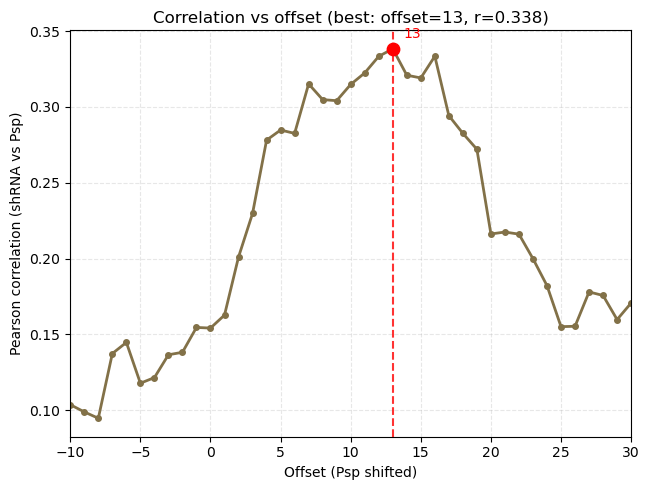

In [2]:
# Prepare clean dataframes
d_shrna = shrna_df[["start_nt_NM_000371.3", "Log2FC_mean"]].copy()
d_shrna["Log2FC_mean"] = pd.to_numeric(d_shrna["Log2FC_mean"], errors="coerce")
d_shrna = d_shrna.dropna(subset=["start_nt_NM_000371.3", "Log2FC_mean"]).sort_values("start_nt_NM_000371.3")

d_psp_base = psp_df[["start_nt_NM_000371.3", "Log2FC_mean"]].copy()
d_psp_base["Log2FC_mean"] = pd.to_numeric(d_psp_base["Log2FC_mean"], errors="coerce")
d_psp_base = d_psp_base.dropna(subset=["start_nt_NM_000371.3", "Log2FC_mean"]).sort_values("start_nt_NM_000371.3")

offset_range = list(range(-10, 31))

results = []
best_corr = -float("inf")
best_offset = None

for offset in offset_range:
    d_psp_tmp = d_psp_base.copy()
    d_psp_tmp["start_nt_NM_000371.3"] = d_psp_tmp["start_nt_NM_000371.3"] + offset

    shared = pd.merge(
        d_shrna, d_psp_tmp,
        on="start_nt_NM_000371.3",
        suffixes=["_shRNA", "_Psp"]
    )

    if shared.empty or shared["Log2FC_mean_shRNA"].nunique() < 2 or shared["Log2FC_mean_Psp"].nunique() < 2:
        corr = float("nan")
    else:
        corr = shared["Log2FC_mean_shRNA"].corr(shared["Log2FC_mean_Psp"], method="pearson")

    if corr > best_corr and not pd.isna(corr):
        best_corr = corr
        best_offset = offset

    results.append({
        "offset": offset,
        "pearson_correlation": corr,
        "n_shared_positions": len(shared)
    })

results_df = pd.DataFrame(results)

# Save correlation table
csv_path = os.path.join(output_dir, "260706_datapoint_offset_correlation_psp_shRNA.csv")
results_df.to_csv(csv_path, index=False)

print("Best offset:", best_offset, "with Pearson r:", best_corr)

# Plot correlation vs offset without data point labels
fig, ax = plt.subplots(figsize=(6.6, 5))

offsets = results_df["offset"]
corrs = results_df["pearson_correlation"]

# Line
ax.plot(offsets, corrs, color="#827148", linewidth=2, marker="o", markersize=4)

# Highlight best offset only
if best_offset is not None:
    best_row = results_df[results_df["offset"] == best_offset].iloc[0]

    # Red dot at highest correlation
    ax.scatter(
        [best_row["offset"]],
        [best_row["pearson_correlation"]],
        color="red",
        s=80,
        zorder=5
    )

    # Red dotted vertical line at best offset
    ax.axvline(
        best_offset,
        color="red",
        linestyle="--",   # dotted/dashed; use ":" for more dotted
        linewidth=1.5,
        alpha=0.8,
        zorder=3
    )

    # Annotation near the highest correlation point
    ax.annotate(
        f"13",
        xy=(best_row["offset"], best_row["pearson_correlation"]),
        xytext=(8, 8),
        textcoords="offset points",
        color="red",
        fontsize=10
    )

ax.set_xlabel("Offset (Psp shifted)")
ax.set_ylabel("Pearson correlation (shRNA vs Psp)")
ax.set_title(f"Correlation vs offset (best: offset={best_offset}, r={best_corr:.3f})")
ax.grid(True, linestyle="--", alpha=0.3)
ax.margins(x=0)

plt.tight_layout()

# pdf_path = os.path.join(output_dir, "260723_datapoint_offset_correlation_psp_shRNA.pdf")
plt.savefig(pdf_path, format="pdf", bbox_inches="tight")
plt.show()